# 07: Generalisation

*How generalisable are the KG's inferences across disease domains and data regimes?*

This notebook evaluates **generalisation** across all loaded KGs on three orthogonal axes, testing whether a knowledge graph that performs well on average also performs equitably — a prerequisite for clinical deployment.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Data-sparse generalisation** | Link prediction performance on the least-annotated drug–disease pairs (lowest-connectivity quartile) | AUROC on Q1-tier pairs (drugs in the lowest quartile by known-indication count); degradation from Q4 → Q1 quantifies structural prevalence bias | Direct AUROC (0–1); no transformation |
| **Cross-domain generalisation** | Consistency of link prediction performance across distinct therapeutic areas | Mean AUROC across therapeutic areas; SD reported to capture cross-area variance (CV > 10% indicates systematic performance inequity) | Mean AUROC (0–1); no transformation |
| **Prospective generalisation** | Ability to predict drug–disease pairs approved after the KG's construction cutoff | AUROC on post-cutoff FDA-approved indication pairs not present in the KG at build time | Direct AUROC (0–1); no transformation |
| **Dimension score** | — | — | Equal-weighted mean of data-sparse AUROC, cross-domain mean AUROC, and prospective AUROC |

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`) · `data/gold_standards/do_diseases.csv` · `data/gold_standards/mesh_to_doid.csv`

**Outputs:** `results/figures/07_*.{pdf,png}` · `results/checkpoints/07_generalization.pkl`

**Dependencies:** `src/loading.py` · `src/graph_utils.py` · `src/scoring.py` · `src/evaluation.py` · `src/negative_sampling.py` · `src/plotting.py`

## Set-up

Three knowledge graphs are evaluated: **Hetionet** (Himmelstein et al., 2017), **DRKG** (Ioannidis et al., 2020), and **PrimeKG** (Chandak et al., 2023). All graphs, node tables, and shared utilities are loaded from the parent-level `src/` module. Link prediction uses Adamic-Adar scoring throughout, consistent with the rest of this benchmark. A fixed random seed (`seed = 42`) and negative-to-positive ratio of 5:1 are used in all sampling procedures.

> Himmelstein, D.S. et al. "Systematic integration of biomedical knowledge prioritizes drugs for repurposing." *eLife* **6**, e26726 (2017)
>
> Ioannidis, N.A. et al. "DRKG — Drug Repurposing Knowledge Graph for COVID-19." *GitHub* (2020)

In [31]:
# Imports
import sys, os, warnings, pickle, math
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from collections import defaultdict, Counter
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import stats
import matplotlib.colors as mcolors

from src.plotting           import (setup_style, clean_ax, save_fig, panel_label,
                                    TEXT_COLOR, TICK_COLOR, ALERT_RED, KG_PALETTE,
                                    OI_BLUE, OI_GREEN, OI_SKY_BLUE, HEATMAP_CMAP)
from src.loading            import find_config, load_config, load_kg
from src.graph_utils        import build_graph, build_lookup_maps, find_node
from src.scoring            import score_adamic_adar
from src.evaluation         import compute_metrics
from src.negative_sampling  import generate_negatives

setup_style()

In [2]:
# Config and paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';        FIGS.mkdir(parents=True, exist_ok=True)

# Spine styling helper (used in all section plots)
def _style_left_spine(ax):
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)

### Loading

In [3]:
# Load KGs
KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

kgs = {}
for name in KG_NAMES:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

LOADED = [n for n in KG_NAMES if n in kgs and config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg']


In [4]:
# Build graphs and lookup maps
graphs, maps = {}, {}
for name, data in kgs.items():
    G            = build_graph(data['kg'], data['nodes'])
    m            = build_lookup_maps(data['nodes'])
    m['node_id_map'] = dict(zip(data['nodes']['idx'], data['nodes']['id']))
    m['id_to_idx']   = dict(zip(data['nodes']['id'],  data['nodes']['idx']))
    graphs[name] = G
    maps[name]   = m
    print(f'{name:12s}: {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges')

primekg     : 129,375 nodes  4,049,642 edges
hetionet    : 47,031 nodes  2,107,709 edges
drkg        : 97,238 nodes  4,400,766 edges
openbilink  : 185,929 nodes  3,200,327 edges
biokg       : 105,524 nodes  2,043,846 edges


### KG configuration

In [5]:
# KG config from config file - not hardcoded
KG_CONFIG = {name: config['knowledge_graphs'][name] for name in LOADED}

def kg_drug_type(name):       return KG_CONFIG[name]['entity_types']['Drug']
def kg_disease_type(name):    return KG_CONFIG[name]['entity_types']['Disease']
def kg_indication_rels(name): return [KG_CONFIG[name]['relations']['drug_disease']['relation']]

In [6]:
# Entity sets, positive pairs, and disease degree
rng       = np.random.RandomState(params.get('random_seed', 42))
NEG_RATIO = params.get('neg_ratio', 1)

kg_entity_sets, kg_pos_pairs, kg_disease_degree = {}, {}, {}

for name in LOADED:
    kg, nodes = kgs[name]['kg'], kgs[name]['nodes']
    dt, dis_t = kg_drug_type(name), kg_disease_type(name)
    ntm       = maps[name]['node_type_map']
    G         = graphs[name]

    drug_idx    = set(nodes[nodes['type'] == dt   ]['idx'])
    disease_idx = set(nodes[nodes['type'] == dis_t]['idx'])

    ind_edges = kg[kg['relation'].isin(kg_indication_rels(name))]
    pos_pairs = list({
        (row.x_index, row.y_index) if ntm.get(row.x_index) == dt
        else (row.y_index, row.x_index)
        for _, row in ind_edges.iterrows()
        if {ntm.get(row.x_index), ntm.get(row.y_index)} == {dt, dis_t}
    })

    kg_entity_sets[name]    = {'drug': drug_idx, 'disease': disease_idx}
    kg_pos_pairs[name]      = pos_pairs
    kg_disease_degree[name] = {d: G.degree(d) for d in disease_idx if G.has_node(d)}

    print(f'{name:12s}: drugs={len(drug_idx):,}  diseases={len(disease_idx):,}  '
          f'indication pairs={len(pos_pairs):,}')

primekg     : drugs=7,957  diseases=17,080  indication pairs=9,388
hetionet    : drugs=1,552  diseases=137  indication pairs=755
drkg        : drugs=24,313  diseases=5,103  indication pairs=4,968
openbilink  : drugs=78,592  diseases=9,510  indication pairs=7,164
biokg       : drugs=8,805  diseases=5,812  indication pairs=66,867


## 1. Data-Sparse Generalisation

Rare and orphan diseases are systematically under-represented in public biomedical data. Whether a KG can still support accurate inference on them is a critical test of generalisation. This section bins diseases by their connectivity (quartile Q1 = rarest, Q4 = most connected) and compares link prediction performance across tiers.

**Protocol:** For each disease quartile, the median AUROC and AUPRC (type-constrained negatives, Adamic-Adar heuristic) are computed using the same train/test split as Section 04. Degradation from Q4 to Q1 quantifies structural prevalence bias.

In [7]:
# Disease connectivity tiers by degree quartile
TIERS = ['Q1: Sparse', 'Q2: Under-studied', 'Q3: Moderate', 'Q4: Well-studied']

kg_degree_df, kg_disease_to_tier = {}, {}

for name in LOADED:
    degs = kg_disease_degree[name]
    degree_df = pd.DataFrame(
        [(d, degs[d]) for d in kg_entity_sets[name]['disease'] if d in degs],
        columns=['disease_idx', 'degree']
    )

    try:
        cuts = pd.qcut(degree_df['degree'], q=4, duplicates='drop')
        degree_df['tier'] = pd.qcut(
            degree_df['degree'], q=4, duplicates='drop',
            labels=TIERS[:len(cuts.cat.categories)]
        )
    except Exception:
        qs = degree_df['degree'].quantile([0.25, 0.5, 0.75])
        degree_df['tier'] = pd.cut(
            degree_df['degree'],
            bins=[-np.inf, qs[0.25], qs[0.50], qs[0.75], np.inf],
            labels=TIERS, include_lowest=True
        )

    kg_degree_df[name]       = degree_df
    kg_disease_to_tier[name] = dict(zip(degree_df['disease_idx'], degree_df['tier']))

    print(f'\n{name} - disease connectivity tiers:')
    print(degree_df.groupby('tier')['degree']
          .agg(['count', 'min', 'max', 'mean']).round(1).to_string())


primekg - disease connectivity tiers:
                   count  min   max  mean
tier                                     
Q1: Sparse          4999    1     2   1.4
Q2: Under-studied   4044    3     6   4.1
Q3: Moderate        3886    7    21  12.5
Q4: Well-studied    4151   22  1524  64.7

hetionet - disease connectivity tiers:
                   count  min   max   mean
tier                                      
Q1: Sparse            35    0    65   39.8
Q2: Under-studied     34   67   151   99.6
Q3: Moderate          34  153   442  251.7
Q4: Well-studied      34  470  1123  692.7

drkg - disease connectivity tiers:
                   count  min   max   mean
tier                                      
Q1: Sparse          1788    1     2    1.3
Q2: Under-studied    912    3     5    3.8
Q3: Moderate        1137    6    17   10.1
Q4: Well-studied    1266   18  8116  152.5

openbilink - disease connectivity tiers:
                   count  min   max  mean
tier                             

In [8]:
# Link prediction performance by disease connectivity tier
tier_results_kg = {}

for name in LOADED:
    G         = graphs[name]
    pos_pairs = kg_pos_pairs[name]
    pos_set   = set(pos_pairs)
    ents      = kg_entity_sets[name]
    nm        = maps[name]['node_name_map']
    tier_results_kg[name] = {}

    print(f'\n{name}')
    print(f'  {"Tier":<24s}  {"N pairs":>8s}  {"AUROC":>7s}  {"AUPRC":>7s}')
    print('  ' + '-' * 56)

    for tier in TIERS:
        tier_diseases = set(
            kg_degree_df[name].loc[kg_degree_df[name]['tier'] == tier, 'disease_idx'])
        tier_pos  = [(d, dis) for d, dis in pos_pairs if dis in tier_diseases]
        sample_n  = min(500, len(tier_pos))

        # Skip tier if no positive pairs exist (avoids zero-length array in compute_metrics)
        if sample_n == 0:
            tier_results_kg[name][tier] = {'n_pos': 0, 'auroc': float('nan'), 'auprc': float('nan')}
            print(f'  {tier:<24s}  {0:>8,}  {"N/A":>7s}  {"N/A":>7s}')
            continue

        sampled   = [tier_pos[i] for i in rng.choice(len(tier_pos), sample_n, replace=False)]
        neg       = generate_negatives(
            sampled, sample_n * NEG_RATIO, 'type-constrained',
            ents['drug'], tier_diseases, {}, nm, pos_set, rng)

        # Also guard against generate_negatives returning nothing (e.g. tiny tier)
        if not sampled or (not neg and len(set([1]*len(sampled))) < 2):
            tier_results_kg[name][tier] = {'n_pos': len(tier_pos), 'auroc': float('nan'), 'auprc': float('nan')}
            print(f'  {tier:<24s}  {len(tier_pos):>8,}  {"N/A":>7s}  {"N/A":>7s}')
            continue

        m         = compute_metrics(score_adamic_adar(G, sampled + neg),
                                    [1] * len(sampled) + [0] * len(neg))
        m['n_pos'] = len(tier_pos)
        tier_results_kg[name][tier] = m
        print(f'  {tier:<24s}  {len(tier_pos):>8,}  {m["auroc"]:7.4f}  {m["auprc"]:7.4f}')



primekg
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                      21   0.6905   0.4841
  Q2: Under-studied              230   0.8343   0.7076
  Q3: Moderate                 1,366   0.9029   0.8076
  Q4: Well-studied             7,771   0.9449   0.7841

hetionet
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                      22   0.7835   0.6259
  Q2: Under-studied               83   0.8915   0.7658
  Q3: Moderate                   245   0.9064   0.6954
  Q4: Well-studied               405   0.8659   0.5825

drkg
  Tier                       N pairs    AUROC    AUPRC
  --------------------------------------------------------
  Q1: Sparse                     180   0.5607   0.2294
  Q2: Under-studied              312   0.8093   0.6427
  Q3: Moderate                   938   0.9166   0.7841
  Q4: Well-studied          

### Generalisation gap

In [9]:
# Generalization gap: relative AUROC drop from Q4 (well-studied) to Q1 (sparse)
def _safe(val, decimals):
    return round(val, decimals) if not np.isnan(val) else None

gen_gaps, rows = {}, []
for name in LOADED:
    r   = tier_results_kg[name]
    q4  = r.get('Q4: Well-studied', {}).get('auroc', np.nan)
    q1  = r.get('Q1: Sparse',       {}).get('auroc', np.nan)
    gap = (q4 - q1) / q4 * 100 if not (np.isnan(q4) or np.isnan(q1) or q4 == 0) else np.nan
    gen_gaps[name] = gap
    rows.append({
        'KG':                        name.upper(),
        'Q4 AUROC (well-studied)':   _safe(q4,  4),
        'Q1 AUROC (sparse)':         _safe(q1,  4),
        'Relative gap (%)':          _safe(gap, 1),
    })

gap_df = pd.DataFrame(rows).set_index('KG')
gap_df.style \
    .set_caption('Sparse-entity generalization gap') \
    .format(na_rep='N/A') \
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '1.0em')]}])

,Q4 AUROC (well-studied),Q1 AUROC (sparse),Relative gap (%)
KG,,,
PRIMEKG,0.944900,0.690500,26.900000
HETIONET,0.865900,0.783500,9.500000
DRKG,0.958100,0.560700,41.500000
OPENBILINK,N/A,0.641600,N/A
BIOKG,0.872900,0.674900,22.700000


  → Saved: 07_sparse_entity_generalization.pdf / .png


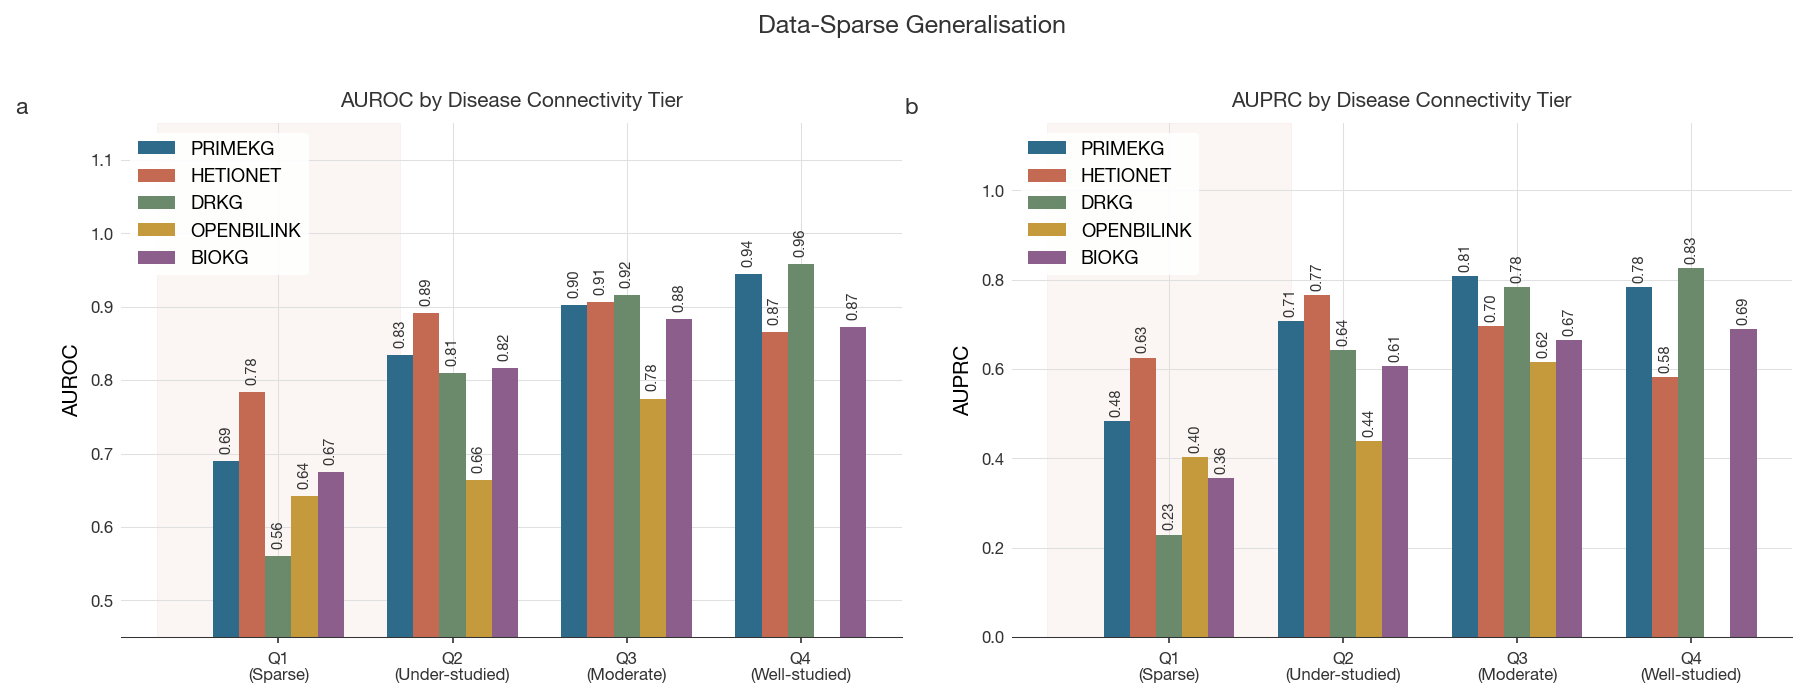

In [30]:
# Sparse-entity generalization: AUROC and AUPRC by connectivity tier
TIER_LABELS = ['Q1\n(Sparse)', 'Q2\n(Under-studied)', 'Q3\n(Moderate)', 'Q4\n(Well-studied)']
METRICS     = [('auroc', 'AUROC', 0.45), ('auprc', 'AUPRC', 0.0)]

shown_kgs = [n for n in LOADED if tier_results_kg.get(n)]
x = np.arange(len(TIERS))
w = 0.15

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (metric, label, ymin), letter in zip(axes, METRICS, 'ab'):
    for i, name in enumerate(shown_kgs):
        vals = [tier_results_kg[name].get(t, {}).get(metric, np.nan) for t in TIERS]
        bars = ax.bar(x + i * w, vals, w, label=name.upper(),
                      color=KG_COLORS[name], edgecolor='none', linewidth=0)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom',
                        fontsize=7, color=TEXT_COLOR, rotation=90)

    # Subtle background shading for sparse region
    ax.axvspan(-0.4, 0.4 + w * (len(shown_kgs) - 1),
               alpha=0.06, color='#C46A52', zorder=0)

    ax.set_xticks(x + w * (len(shown_kgs) - 1) / 2)
    ax.set_xticklabels(TIER_LABELS, fontsize=10)
    ax.set_ylim(ymin, 1.15)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none',
              framealpha=0.9, loc='upper left')
    _style_left_spine(ax)
    clean_ax(ax, title=f'{label} by Disease Connectivity Tier')
    panel_label(ax, letter)

plt.suptitle('Data-Sparse Generalisation',
             fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '07_sparse_entity_generalization')
plt.show()

## 2. Cross-Domain Generalisation

A KG optimised for one disease domain may fail to generalise to others. This section partitions drug–disease pairs by therapeutic area (curated from DrugBank) and computes AUROC per area. Systematic variation in performance (high CV% or significant Kruskal-Wallis *H*) indicates domain-specific bias.

**Protocol:** Performance is stratified by disease domain; CV > 10% signals meaningful inequity. Domains with <5 test pairs are excluded.

### Disease categorisation

In [11]:
# Ontology bridge tables for disease name resolution
_do_df        = pd.read_csv(BASE / 'data/gold_standards/do_diseases.csv')
_doid_to_name = dict(zip(_do_df['doid'].astype(str), _do_df['mondo_name'].astype(str)))

_mesh_df = pd.read_csv(BASE / 'data/gold_standards/mesh_to_doid.csv', on_bad_lines='skip')
_mesh_df['mesh_clean'] = _mesh_df['mesh_id'].astype(str).str.split(' ').str[0]
_mesh_to_doid = (_mesh_df.drop_duplicates(subset='mesh_clean')
                 .set_index('mesh_clean')['doid'].astype(str).to_dict())

# Curated MESH supplement - high-frequency DRKG nodes absent from cross-mapping file
MESH_NAME_SUPPLEMENT = {
    'MESH:D006973': 'hypertension cardiovascular',
    'MESH:D006333': 'heart failure cardiac',
    'MESH:D001171': 'arthritis joint disease',
    'MESH:D017192': 'hepatitis c infection viral',
    'MESH:D006255': 'rhinitis allergic seasonal hay fever',
    'MESH:D010146': 'pain neuropathic chronic',
    'MESH:D003865': 'major depressive disorder',
    'MESH:D006470': 'hemorrhage cardiovascular',
    'MESH:D010003': 'osteoarthritis joint arthritis',
    'MESH:D006356': 'opioid substance dependence',
    'MESH:D020521': 'stroke cerebrovascular',
    'MESH:D003928': 'diabetic nephropathies diabetes',
    'MESH:D012221': 'rhinitis allergic perennial',
    'MESH:D019698': 'hepatitis c chronic infection viral',
    'MESH:D003866': 'depressive disorder',
    'MESH:D000341': 'agitation psychomotor anxiety',
    'MESH:D011537': 'psoriasis skin autoimmune',
    'MESH:D007319': 'leukemia cancer',
    'MESH:D059413': 'heart failure cardiac',
    'MESH:D000077': 'amyotrophic lateral sclerosis neurodegenerat',
    'MESH:D065631': 'thrombosis cardiovascular',
    'MESH:D009103': 'multiple sclerosis neurology',
    'MESH:D009765': 'obesity metabolic',
    'MESH:D006509': 'hepatitis b infection viral',
    'MESH:D007938': 'leukemia cancer',
    'MESH:D009101': 'multiple myeloma cancer',
    'MESH:D008223': 'lymphoma cancer',
    'MESH:D000755': 'anemia hematology',
    'MESH:D001289': 'attention deficit hyperactivity adhd',
    'MESH:D003920': 'diabetes mellitus metabolic diabet',
    'MESH:D006693': 'hodgkin lymphoma cancer',
    'MESH:D003324': 'coronary artery disease cardiac',
    'MESH:D003072': 'cognitive impairment dementia',
    'MESH:D016212': 'follicular lymphoma cancer neoplasm',
    'MESH:D007715': 'kidney failure renal',
    'MESH:D008103': 'liver cirrhosis hepatic',
    'MESH:D018580': 'anxiety disorder psychiatric',
    'MESH:D001714': 'bipolar disorder psychiatric',
    'MESH:D013167': 'ankylosing spondylitis arthritis autoimmune',
    'MESH:D015535': 'psoriatic arthritis autoimmune',
    'MESH:D015658': 'hiv infection',
    'MESH:D001943': 'breast carcinoma cancer',
    'MESH:D014552': 'urinary tract infection',
    'MESH:D000152': 'acne skin',
    'MESH:D001007': 'anxiety disorders psychiatric',
    'MESH:D015179': 'colorectal cancer neoplasm',
    'MESH:D008175': 'lung cancer neoplasm',
    'MESH:D011467': 'prostate cancer neoplasm',
    'MESH:D009422': 'nervous system disease neurology',
    'MESH:D007239': 'infections bacterial',
    'MESH:D005355': 'fibrosis pulmonary respiratory',
    'MESH:D008288': 'malaria infection',
    'MESH:D012559': 'schizophrenia psychiatric',
    'MESH:D004194': 'disease broad',
    'MESH:D016889': 'endometrial cancer carcinoma',
    'MESH:D019337': 'hematologic neoplasm leukemia cancer',
}

# Reverse maps - used in prospective resolution (Section 3)
_name_to_doid = (_do_df.drop_duplicates(subset='mondo_name')
                 .assign(key=_do_df['mondo_name'].str.lower().str.strip())
                 .set_index('key')['doid'].astype(str).to_dict())

_doid_to_mesh = (_mesh_df.drop_duplicates(subset='doid')
                 .set_index('doid')['mesh_clean'].astype(str).to_dict())

In [12]:
# Disease name resolution and therapeutic area classification
AREA_KEYWORDS = {
    'Oncology':       ['cancer', 'carcinoma', 'leukemia', 'lymphoma', 'tumor', 'neoplasm',
                       'melanoma', 'sarcoma', 'myeloma', 'glioma', 'blastoma'],
    'Cardiovascular': ['heart', 'cardiac', 'hypertens', 'coronary', 'arrhyth',
                       'atheroscl', 'cardiomyop', 'hemorrhag', 'thrombos', 'ischemi'],
    'Neurology':      ['alzheimer', 'parkinson', 'epilepsy', 'dementia', 'sclerosis',
                       'neuropath', 'huntington', 'migraine', 'seizure', 'cerebrovascular',
                       'neurodegenerat'],
    'Metabolic':      ['diabet', 'obesity', 'metabolic', 'thyroid', 'hyperlipid', 'gout',
                       'insulin', 'hyperglycemi'],
    'Immunology':     ['autoimmune', 'lupus', 'rheumatoid', 'psoriasis', 'crohn',
                       'colitis', 'allerg', 'arthritis', 'spondylitis', 'eczema', 'atopic'],
    'Infectious':     ['infect', 'bacterial', 'viral', 'tuberculosis', 'hiv',
                       'hepatitis', 'malaria', 'pneumonia', 'influenza', 'herpes'],
    'Respiratory':    ['asthma', 'copd', 'pulmonary', 'respiratory', 'fibrosis', 'bronchit'],
    'Psychiatry':     ['schizophren', 'bipolar', 'depress', 'anxiety', 'psycho',
                       'adhd', 'autism', 'dependence', 'substance', 'agitation'],
}

def _resolve_disease_name(node_id: str, kg_name: str) -> str:
    """Resolve a disease node ID/name to a lowercase string for keyword matching.

    Fully KG-agnostic: resolution is driven by node_id content, not KG name.
    - 'DOID:10021'       -> ontology lookup (DRKG)
    - 'MESH:D007052'     -> MESH supplement or MESH->DOID bridge (DRKG)
    - '10021'            -> bare DOID numeric fallback (OpenBioLink)
    - 'alzheimer disease'-> returned as-is (PrimeKG, Hetionet)
    """
    # Content-driven resolution — no hardcoded KG names needed.
    if node_id.startswith('DOID:'):
        return _doid_to_name.get(node_id, '').lower()
    if node_id.startswith('MESH:'):
        if node_id in MESH_NAME_SUPPLEMENT:
            return MESH_NAME_SUPPLEMENT[node_id].lower()
        doid = _mesh_to_doid.get(node_id)
        return _doid_to_name.get(doid, '').lower() if doid else ''
    # Bare numeric: OpenBioLink node_name_map stores '10021' not 'DOID:10021'
    # because _name_from_id strips the prefix — try prepending 'DOID:'.
    candidate = _doid_to_name.get('DOID:' + node_id, '')
    if candidate:
        return candidate.lower()
    # Human-readable name (PrimeKG, Hetionet) — return directly.
    return node_id.lower()

def _assign_area(dname: str):
    for area, kws in AREA_KEYWORDS.items():
        if any(k in dname for k in kws):
            return area
    return None

kg_disease_to_area, kg_area_coverage = {}, {}

for name in LOADED:
    nm  = maps[name]['node_name_map']
    d2a = {
        d: area
        for d in kg_entity_sets[name]['disease']
        if (area := _assign_area(_resolve_disease_name(str(nm.get(d, '')), name)))
    }
    kg_disease_to_area[name] = d2a
    n_dis    = len(kg_entity_sets[name]['disease'])
    coverage = len(d2a) / max(1, n_dis) * 100
    kg_area_coverage[name] = coverage

    area_pair_counts = Counter(
        d2a.get(dis) for _, dis in kg_pos_pairs[name] if d2a.get(dis))

    print(f'\n{name} - disease categorisation ({len(d2a):,}/{n_dis:,} = {coverage:.1f}%):')
    print(f'  {"Area":<16s}  {"Diseases":>9s}  {"Ind. pairs":>10s}')
    print('  ' + '-' * 40)
    for area in sorted(AREA_KEYWORDS):
        cnt_d = sum(1 for v in d2a.values() if v == area)
        cnt_p = area_pair_counts.get(area, 0)
        flag  = '  ok' if cnt_p >= 25 else '  (< 25 pairs, excluded)'
        print(f'  {area:<16s}  {cnt_d:>9,}  {cnt_p:>10,}{flag}')


primekg - disease categorisation (4,966/17,080 = 29.1%):
  Area               Diseases  Ind. pairs
  ----------------------------------------
  Cardiovascular          393         347  ok
  Immunology              204         731  ok
  Infectious              451         792  ok
  Metabolic               273         283  ok
  Neurology               530         411  ok
  Oncology              2,877       1,585  ok
  Psychiatry               71         274  ok
  Respiratory             167         211  ok

hetionet - disease categorisation (93/137 = 67.9%):
  Area               Diseases  Ind. pairs
  ----------------------------------------
  Cardiovascular            4         105  ok
  Immunology               10         118  ok
  Infectious                2          15  (< 25 pairs, excluded)
  Metabolic                 7          49  ok
  Neurology                 8          49  ok
  Oncology                 54         284  ok
  Psychiatry                5           5  (< 25 pairs,

### Evaluation

In [13]:
# Bootstrap CI and per-area evaluation config
N_BOOTSTRAP = params.get('n_bootstrap', 1000)
MIN_PAIRS   = params.get('min_pairs_per_area', 25)

def bootstrap_auroc_ci(scores: np.ndarray, labels: np.ndarray,
                        n_boot: int = N_BOOTSTRAP) -> tuple:
    """Percentile bootstrap 95% CI for AUROC.
    Returns (mean, ci_lo, ci_hi) or (nan, nan, nan) if insufficient samples.
    """
    n = len(scores)
    if labels.sum() < 2 or (1 - labels).sum() < 2:
        return np.nan, np.nan, np.nan
    boots = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if 0 < labels[idx].sum() < n:
            try:
                boots.append(roc_auc_score(labels[idx], scores[idx]))
            except Exception:
                continue
    if len(boots) < 10:
        return np.nan, np.nan, np.nan
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(np.mean(boots)), float(lo), float(hi)

In [14]:
# Per-area link prediction performance
area_results_kg, area_cv = {}, {}

for name in LOADED:
    G, pos_pairs = graphs[name], kg_pos_pairs[name]
    d2a          = kg_disease_to_area[name]
    drug_idx     = kg_entity_sets[name]['drug']
    nm           = maps[name]['node_name_map']
    pos_set      = set(pos_pairs)
    area_results_kg[name] = {}
    kw_groups, kw_labels  = [], []

    print(f'\n{name}')
    print(f'  {"Area":<16s}  {"Diseases":>9s}  {"Pairs":>7s}  '
          f'{"AUROC":>7s}  {"95% CI":>18s}  {"AUPRC":>7s}')
    print('  ' + '-' * 78)

    for area in sorted(AREA_KEYWORDS):
        area_diseases = {d for d, a in d2a.items() if a == area}
        area_pos      = [(d, dis) for d, dis in pos_pairs if dis in area_diseases]
        n_d, n_p      = len(area_diseases), len(area_pos)

        if n_p < MIN_PAIRS:
            area_results_kg[name][area] = {
                'n_diseases': n_d, 'n_pos': n_p,
                'auroc': np.nan, 'auprc': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan,
            }
            print(f'  {area:<16s}  {n_d:>9,}  {n_p:>7,}  '
                  f'{"N/A":>7s}  {"(insufficient pairs)":>18s}  {"N/A":>7s}')
            continue

        sample_n   = min(500, n_p)
        sampled    = [area_pos[i] for i in rng.choice(n_p, sample_n, replace=False)]
        neg        = generate_negatives(sampled, sample_n * NEG_RATIO, 'type-constrained',
                                        drug_idx, area_diseases, {}, nm, pos_set, rng)
        scores_arr = np.array(score_adamic_adar(G, sampled + neg))
        labels_arr = np.array([1] * len(sampled) + [0] * len(neg))

        m             = compute_metrics(scores_arr.tolist(), labels_arr.tolist())
        _, ci_lo, ci_hi = bootstrap_auroc_ci(scores_arr, labels_arr)
        m.update({'n_diseases': n_d, 'n_pos': n_p, 'ci_lo': ci_lo, 'ci_hi': ci_hi})
        area_results_kg[name][area] = m

        kw_groups.append(scores_arr[:len(sampled)].tolist())
        kw_labels.append(area)

        ci_str = f'[{ci_lo:.3f}, {ci_hi:.3f}]' if not np.isnan(ci_lo) else 'N/A'
        print(f'  {area:<16s}  {n_d:>9,}  {n_p:>7,}  '
              f'{m["auroc"]:7.4f}  {ci_str:>18s}  {m["auprc"]:7.4f}')

    vals = [r['auroc'] for r in area_results_kg[name].values()
            if not np.isnan(r.get('auroc', np.nan))]

    if len(vals) >= 2:
        cv  = np.std(vals) / np.mean(vals) * 100
        area_cv[name] = cv
        kw_note = ''
        if len(kw_groups) >= 2:
            kw_stat, kw_p = stats.kruskal(*kw_groups)
            sig     = '***' if kw_p < 0.001 else ('**' if kw_p < 0.01 else ('*' if kw_p < 0.05 else 'ns'))
            kw_note = f'  Kruskal-Wallis H = {kw_stat:.2f}, p = {kw_p:.4f} ({sig})'
        print(f'\n  Mean AUROC: {np.mean(vals):.4f}  SD: {np.std(vals):.4f}  '
              f'CV: {cv:.1f}%  Range: {max(vals) - min(vals):.4f}')
        if kw_note:
            print(kw_note)
    else:
        area_cv[name] = np.nan
        print('\n  [Insufficient areas with >= 25 pairs for variance summary]')


primekg
  Area               Diseases    Pairs    AUROC              95% CI    AUPRC
  ------------------------------------------------------------------------------
  Cardiovascular          393      347   0.9834      [0.975, 0.991]   0.9488
  Immunology              204      731   0.9692      [0.961, 0.977]   0.8666
  Infectious              451      792   0.9288      [0.914, 0.943]   0.8093
  Metabolic               273      283   0.9817      [0.974, 0.989]   0.9006
  Neurology               530      411   0.9846      [0.977, 0.991]   0.9435
  Oncology              2,877    1,585   0.9674      [0.957, 0.977]   0.9190
  Psychiatry               71      274   0.9755      [0.968, 0.982]   0.8533
  Respiratory             167      211   0.9478      [0.927, 0.966]   0.8687

  Mean AUROC: 0.9673  SD: 0.0184  CV: 1.9%  Range: 0.0558
  Kruskal-Wallis H = 777.65, p = 0.0000 (***)

hetionet
  Area               Diseases    Pairs    AUROC              95% CI    AUPRC
  -----------------------

In [15]:
# Cross-KG variance summary
print(f'{"KG":12s}  {"Mean AUROC":>12s}  {"SD":>6s}  {"CV%":>6s}  {"N areas":>7s}')
print('-' * 54)
for name in LOADED:
    vals = [r['auroc'] for r in area_results_kg[name].values()
            if not np.isnan(r.get('auroc', np.nan))]
    if vals:
        print(f'{name:12s}  {np.mean(vals):12.4f}  {np.std(vals):6.4f}  '
              f'{area_cv.get(name, np.nan):6.1f}  {len(vals):>7d}')
    else:
        print(f'{name:12s}  {"N/A":>12s}  {"N/A":>6s}  {"N/A":>6s}  {"0":>7s}')

KG              Mean AUROC      SD     CV%  N areas
------------------------------------------------------
primekg             0.9673  0.0184     1.9        8
hetionet            0.9089  0.0112     1.2        6
drkg                0.9625  0.0114     1.2        8
openbilink          0.8387  0.0796     9.5        8
biokg               0.8793  0.0400     4.6        8


### Visualisation

  → Saved: 07a_cross_domain_heatmap.pdf / .png


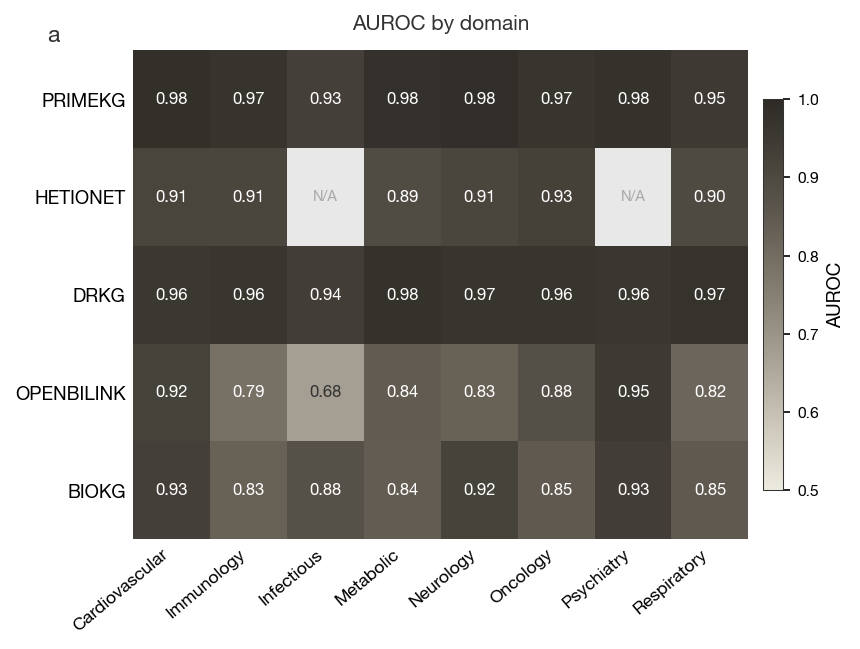

In [32]:
# Cross-domain generalization: AUROC heatmap
shown_kgs   = [n for n in LOADED if area_results_kg.get(n)]
valid_areas = sorted([
    a for a in AREA_KEYWORDS
    if any(not np.isnan(area_results_kg[n].get(a, {}).get('auroc', np.nan))
           for n in shown_kgs)
])

n_areas = len(valid_areas)
n_kgs   = len(shown_kgs)

fig, ax = plt.subplots(figsize=(max(6.0, n_areas * 0.72), max(2.4, n_kgs * 0.72 + 0.8)))

heat_data = np.array([
    [area_results_kg[n].get(a, {}).get('auroc', np.nan) for a in valid_areas]
    for n in shown_kgs
])

cmap_use = HEATMAP_CMAP

im = ax.pcolormesh(np.where(~np.isnan(heat_data), heat_data, np.nan),
                   cmap=cmap_use, vmin=0.5, vmax=1.0,
                   edgecolors='none', linewidth=0, antialiased=False)

# N/A cells as light grey
na_mask = np.where(np.isnan(heat_data), 1, np.nan)
ax.pcolormesh(na_mask, cmap=mcolors.ListedColormap(['#e8e8e8']),
              vmin=0, vmax=1,
              edgecolors='none', linewidth=0, antialiased=False)

ax.set_xticks([x + 0.5 for x in range(n_areas)])
ax.set_xticklabels(valid_areas, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks([y + 0.5 for y in range(n_kgs)])
ax.set_yticklabels([n.upper() for n in shown_kgs], fontsize=9)
ax.tick_params(length=0, which='both')
ax.grid(False, which='both')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

for i, name in enumerate(shown_kgs):
    for j, area in enumerate(valid_areas):
        val = heat_data[i, j]
        if not np.isnan(val):
            text_col = 'white' if val > 0.72 else TEXT_COLOR
            ax.text(j + 0.5, i + 0.5, f'{val:.2f}',
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color=text_col)
        else:
            ax.text(j + 0.5, i + 0.5, 'N/A',
                    ha='center', va='center', fontsize=7,
                    color='#aaaaaa', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.80, pad=0.02, label='AUROC')
cbar.ax.tick_params(labelsize=7.5)
ax.set_title('AUROC by domain', fontsize=10, fontweight='bold',
             color=TEXT_COLOR, pad=10)
panel_label(ax, 'a')
plt.tight_layout()
save_fig(fig, FIGS, '07a_cross_domain_heatmap')
plt.show()

  → Saved: 07c_cross_domain_cv.pdf / .png


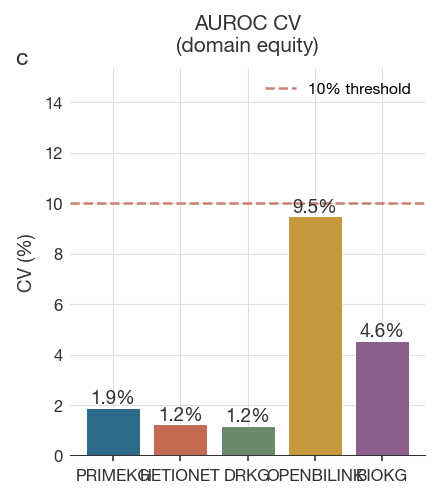

In [17]:
# Cross-domain generalization: AUROC coefficient of variation per KG
shown_kgs = [n for n in LOADED if area_results_kg.get(n)]

fig, ax = plt.subplots(figsize=(3.0, 3.4))

cv_kgs  = [n for n in shown_kgs if not np.isnan(area_cv.get(n, np.nan))]
cv_vals = [area_cv[n] for n in cv_kgs]
bars    = ax.bar(range(len(cv_kgs)), cv_vals,
                 color=[KG_COLORS[n] for n in cv_kgs], edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, cv_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold', color=TEXT_COLOR)
ax.axhline(10, color=ALERT_RED, ls='--', lw=1.2, alpha=0.85, label='10% threshold')
ax.set_xticks(range(len(cv_kgs)))
ax.set_xticklabels([n.upper() for n in cv_kgs], fontsize=8.5)
ax.set_ylim(0, max(cv_vals + [12]) * 1.28)
ax.legend(fontsize=7.5, frameon=False)
_style_left_spine(ax)
clean_ax(ax, title='AUROC CV\n(domain equity)', ylabel='CV (%)')
panel_label(ax, 'c')
plt.tight_layout()
save_fig(fig, FIGS, '07c_cross_domain_cv')
plt.show()

## 3. Prospective Generalisation

A prospective evaluation tests whether a KG's topology encodes signal for indications approved *after* the KG's data cutoff. Fifty drug–indication pairs approved by the FDA between the data cutoff of each KG and June 2024 form a held-out gold standard. Success on this held-out set is evidence of structural, not just memorised, encoding.

**Protocol:** Prospective pairs are ranked using the Adamic-Adar heuristic (no retraining) against negative samples using the same strategies as Section 04. Metrics are AUROC, MRR, and Hits@10.

### FDA approvals dataset

In [18]:
# Post-cutoff FDA supplemental approvals - ground truth for prospective validation
# Sources: FDA Drugs@FDA (Efficacy Supplements), FDA approval letters.
# Format: DrugBank ID -> (drug name, [(disease term, approval date, description)])
NEW_INDICATION_APPROVALS = {
    'DB12159': ('dupilumab',       [('chronic obstructive pulmonary disease', '2024-09-27', 'COPD with eosinophilic phenotype'),
                                    ('prurigo nodularis',                     '2024-10-25', 'Prurigo nodularis in adults')]),
    'DB13928': ('semaglutide',     [('cardiovascular disease',  '2024-03-08', 'CV risk reduction in overweight/obese adults'),
                                    ('obstructive sleep apnea', '2024-12-13', 'Moderate-to-severe OSA with obesity')]),
    'DB09037': ('pembrolizumab',   [('endometrial carcinoma',                    '2024-06-07', 'Advanced endometrial carcinoma (1L)'),
                                    ('cervical cancer',                          '2024-01-15', 'Persistent/recurrent/metastatic cervical cancer'),
                                    ('gastric cancer',                           '2024-10-25', 'HER2+ gastric/GEJ adenocarcinoma (1L)'),
                                    ('gastroesophageal junction adenocarcinoma', '2024-10-25', 'HER2+ GEJ adenocarcinoma'),
                                    ('hepatocellular carcinoma',                 '2024-09-03', 'HCC (1L with lenvatinib)')]),
    'DB09035': ('nivolumab',       [('hepatocellular carcinoma', '2024-08-15', 'HCC (1L with ipilimumab)'),
                                    ('colorectal cancer',        '2024-07-25', 'MSI-H/dMMR CRC'),
                                    ('esophageal cancer',        '2024-03-22', 'Resectable esophageal/GEJ cancer (neoadjuvant)')]),
    'DB11714': ('durvalumab',      [('small cell lung carcinoma', '2024-12-20', 'Limited-stage SCLC'),
                                    ('biliary tract neoplasm',    '2024-09-05', 'Biliary tract cancer (1L)')]),
    'DB11595': ('atezolizumab',    [('hepatocellular carcinoma', '2023-10-15', 'Unresectable HCC (with bevacizumab)')]),
    'DB00051': ('adalimumab',      [('hidradenitis suppurativa', '2024-04-30', 'HS in adolescents 12+ years')]),
    'DB09053': ('ibrutinib',       [('chronic lymphocytic leukemia/small lymphocytic lymphoma', '2023-12-01', 'CLL/SLL (1L and relapsed)'),
                                    ('follicular lymphoma',                                     '2024-03-29', 'Relapsed/refractory FL')]),
    'DB11581': ('venetoclax',      [('bilineal acute myeloid leukemia', '2024-01-12', 'Newly diagnosed AML (with azacitidine)'),
                                    ('myelodysplastic syndrome',        '2024-06-14', 'Higher-risk MDS')]),
    'DB11703': ('acalabrutinib',   [('chronic lymphocytic leukemia/small lymphocytic lymphoma', '2024-05-20', 'CLL/SLL (1L and relapsed)')]),
    'DB09074': ('olaparib',        [('prostate cancer, hereditary', '2023-12-19', 'mCRPC with HRR gene mutations'),
                                    ('breast cancer',               '2024-03-11', 'Adjuvant HER2- high-risk early breast cancer')]),
    'DB00072': ('trastuzumab',     [('gastric cancer', '2024-06-13', 'HER2+ metastatic gastric cancer (updated regimen)')]),
    'DB09078': ('lenvatinib',      [('endometrial cancer', '2024-06-07', 'Advanced endometrial carcinoma (with pembrolizumab)')]),
    'DB06292': ('dapagliflozin',   [('heart failure',           '2023-08-10', 'Heart failure across LVEF spectrum'),
                                    ('congestive heart failure', '2023-08-10', 'HFrEF and HFpEF')]),
    'DB09038': ('empagliflozin',   [('heart failure', '2023-09-15', 'Heart failure across LVEF spectrum')]),
    'DB08877': ('ruxolitinib',     [('alopecia areata', '2023-08-14', 'Alopecia areata (topical)'),
                                    ('vitiligo',        '2023-10-18', 'Non-segmental vitiligo (topical)')]),
    'DB08879': ('belimumab',       [('lupus nephritis', '2024-06-01', 'Active lupus nephritis (expanded)')]),
    'DB15091': ('upadacitinib',    [('ulcerative colitis',     '2023-08-16', 'Moderately-to-severely active UC'),
                                    ('Crohn disease',          '2024-05-17', 'Moderately-to-severely active CD'),
                                    ('ankylosing spondylitis', '2024-02-13', 'Active AS'),
                                    ('atopic eczema',          '2024-01-25', 'Moderate-to-severe AD (expanded age)')]),
    'DB14762': ('risankizumab',    [('Crohn disease',      '2023-08-02', 'Moderately-to-severely active Crohn disease'),
                                    ('ulcerative colitis', '2024-09-19', 'Moderately-to-severely active UC')]),
    'DB06273': ('tocilizumab',     [('systemic lupus erythematosus', '2024-03-06', 'Expanded systemic autoimmune indications')]),
    'DB08875': ('cabozantinib',    [('hepatocellular carcinoma', '2024-02-28', 'Previously treated HCC')]),
    'DB09331': ('daratumumab',     [('plasma cell myeloma', '2024-03-25', 'Newly diagnosed transplant-eligible MM (expanded)')]),
    'DB01590': ('everolimus',      [('gastrointestinal stromal tumor', '2024-05-09', 'Advanced GI NETs (expanded)')]),
}

In [19]:
# Disease name resolution helpers for prospective evaluation
# (uses _name_to_doid and _doid_to_mesh built in the ontology bridge cell above)

# FDA approval terms that differ from DO nomenclature
TEMPORAL_DISEASE_ALIASES = {
    'bilineal acute myeloid leukemia':          'acute myeloid leukemia',
    'heart failure':                            'congestive heart failure',
    'prostate cancer, hereditary':              'prostate cancer',
    'gastroesophageal junction adenocarcinoma': 'esophageal adenocarcinoma',
    'biliary tract neoplasm':                   'biliary tract cancer',
    'obstructive sleep apnea':                  'obstructive sleep apnea syndrome',
}

def _resolve_drkg_disease(term: str, drkg_dis_rev: dict):
    for t in [term.lower(), TEMPORAL_DISEASE_ALIASES.get(term.lower(), '')]:
        if not t:
            continue
        doid = _name_to_doid.get(t)
        if not doid:
            continue
        doid_node = 'DOID:' + doid.split(':')[1] if ':' in doid else None
        if doid_node and doid_node in drkg_dis_rev:
            return drkg_dis_rev[doid_node]
        mesh = _doid_to_mesh.get(doid)
        if mesh and mesh in drkg_dis_rev:
            return drkg_dis_rev[mesh]
    return None

# Build reverse DrugBank-ID -> node_idx map for OpenBioLink drug lookup
# (OpenBioLink drug nodes use PUBCHEM.COMPOUND:* IDs; gold standard uses DrugBank IDs)
_obl_db_to_idx = {}
if 'openbilink' in kgs:
    _obl_nodes = kgs['openbilink']['nodes']
    _obl_mask  = (
        (_obl_nodes['type'] == 'Drug') &
        _obl_nodes['drugbank_id'].str.startswith('DB', na=False)
    )
    _obl_db_to_idx = dict(zip(
        _obl_nodes.loc[_obl_mask, 'drugbank_id'],
        _obl_nodes.loc[_obl_mask, 'idx'],
    ))

def find_drug_in_kg(dbid: str, drug_name: str, kg_name: str):
    nm, tm = maps[kg_name]['node_name_map'], maps[kg_name]['node_type_map']
    dt     = kg_drug_type(kg_name)
    if kg_name in ('primekg', 'biokg'):
        return maps[kg_name]['id_to_idx'].get(dbid)
    if kg_name == 'drkg':
        return find_node(dbid, nm, tm, dt)
    if kg_name == 'openbilink':
        # Drug nodes are keyed by PUBCHEM.COMPOUND:* — map DrugBank ID via pre-built index
        return _obl_db_to_idx.get(dbid)
    return find_node(drug_name, nm, tm, dt)

def find_disease_in_kg(term: str, kg_name: str, disease_name_to_idx: dict):
    # Both DRKG and OpenBioLink use DOID:* disease node IDs — resolve via ontology
    if kg_name in ('drkg', 'openbilink'):
        return _resolve_drkg_disease(term, disease_name_to_idx)
    t     = term.lower()
    d2i   = disease_name_to_idx
    if t in d2i:
        return d2i[t]
    cands = sorted([(n, i) for n, i in d2i.items() if t in n], key=lambda x: len(x[0]))
    return cands[0][1] if cands else None

# Build disease name -> index maps per KG
disease_name_to_idx_kg = {}
for name in LOADED:
    if name in ('drkg', 'openbilink'):
        # Both route disease lookups through _resolve_drkg_disease, which uses bare CURIEs
        # like 'MESH:D001234' or 'DOID:10021'. Build the map with those bare keys:
        #   DRKG:        id_to_idx key = 'Disease::MESH:D001234' → strip '::' prefix → 'MESH:D001234'
        #   OpenBioLink: id_to_idx key = 'DOID:10021'            → no '::' → unchanged
        dis_t = kg_disease_type(name)
        disease_name_to_idx_kg[name] = {
            (node_id.split('::', 1)[-1] if '::' in node_id else node_id): idx
            for node_id, idx in maps[name]['id_to_idx'].items()
            if maps[name]['node_type_map'].get(idx) == dis_t
        }
        continue
    kg_data = kgs[name]['kg']
    dst     = kg_disease_type(name)
    d2i     = {}
    for ci, cn, ct in [('x_index', 'x_name', 'x_type'), ('y_index', 'y_name', 'y_type')]:
        sub = kg_data[kg_data[ct] == dst][[ci, cn]].drop_duplicates(ci)
        for _, row in sub.iterrows():
            d2i[str(row[cn]).lower()] = row[ci]
    disease_name_to_idx_kg[name] = d2i


In [20]:
# Resolve FDA approval pairs per KG and build existing indication sets
existing_ind_kg, temporal_pairs_kg = {}, {}

for name in LOADED:
    kg_data        = kgs[name]['kg']
    ntm            = maps[name]['node_type_map']
    dt, dst        = kg_drug_type(name), kg_disease_type(name)
    dis_rev        = disease_name_to_idx_kg[name]

    ind_edges = kg_data[kg_data['relation'].isin(kg_indication_rels(name))]
    exist_ind = {
        (row.x_index, row.y_index) if ntm.get(row.x_index) == dt else (row.y_index, row.x_index)
        for _, row in ind_edges.iterrows()
        if {ntm.get(row.x_index), ntm.get(row.y_index)} == {dt, dst}
    }
    existing_ind_kg[name] = exist_ind

    pairs, unmatched_d, unmatched_dis = [], [], []
    for dbid, (drug_name, indications) in NEW_INDICATION_APPROVALS.items():
        drug_node = find_drug_in_kg(dbid, drug_name, name)
        if drug_node is None or not graphs[name].has_node(drug_node) \
                or graphs[name].degree(drug_node) < 5:
            unmatched_d.append(dbid)
            continue
        for disease_term, approval_date, desc in indications:
            dis_idx = find_disease_in_kg(disease_term, name, dis_rev)
            if dis_idx is None:
                unmatched_dis.append((dbid, drug_name, disease_term))
                continue
            pairs.append((drug_node, dis_idx, approval_date, drug_name,
                          maps[name]['node_name_map'].get(dis_idx, disease_term)))

    seen, unique = set(), []
    for p in pairs:
        if (p[0], p[1]) not in seen:
            seen.add((p[0], p[1]))
            unique.append(p)

    temporal_pairs_kg[name] = {
        'new':                [p for p in unique if (p[0], p[1]) not in exist_ind],
        'leaked':             [p for p in unique if (p[0], p[1]) in exist_ind],
        'unmatched_drugs':    unmatched_d,
        'unmatched_diseases': unmatched_dis,
    }

n_total = len(NEW_INDICATION_APPROVALS)
print(f'{"KG":12s}  {"Drugs found":>12s}  {"New pairs":>10s}  {"Leaked":>8s}  '
      f'{"Drug miss":>10s}  {"Dis miss":>9s}')
print('-' * 70)
for name in LOADED:
    tp   = temporal_pairs_kg[name]
    n_dr = n_total - len(tp['unmatched_drugs'])
    print(f'{name:12s}  {n_dr:>5}/{n_total:<6}  {len(tp["new"]):>10,}  '
          f'{len(tp["leaked"]):>8,}  {len(tp["unmatched_drugs"]):>10,}  '
          f'{len(tp["unmatched_diseases"]):>9,}')

KG             Drugs found   New pairs    Leaked   Drug miss   Dis miss
----------------------------------------------------------------------
primekg          23/23              39         2           0          0
hetionet          3/23               2         0          20          3
drkg             23/23              32         2           0          6
openbilink        7/23               9         0          16          0
biokg            23/23              14         2           0         25


### Evaluation

In [21]:
# Prospective evaluation config and graph construction
MIN_PAIRS = 20  # require ≥20 evaluable pairs for a reliable AUROC estimate

temporal_metrics_kg, temporal_graphs_kg = {}, {}
temporal_ranks_kg, baseline_all_kg, baseline_same_kg = {}, {}, {}

def _eval_pairs(pairs, n, G_eval, exclude_set, d_pool, dis_pool, nm):
    samp = [pairs[i] for i in rng.choice(len(pairs), min(n, len(pairs)), replace=False)]
    neg  = generate_negatives(samp, len(samp) * NEG_RATIO, 'type-constrained',
                               d_pool, dis_pool, {}, nm, exclude_set, rng)
    return compute_metrics(score_adamic_adar(G_eval, samp + neg),
                           [1]*len(samp) + [0]*len(neg))

In [22]:
# Prospective evaluation — main loop
# Populates: temporal_metrics_kg, temporal_ranks_kg, baseline_all_kg, baseline_same_kg

for name in LOADED:
    tp_info   = temporal_pairs_kg[name]
    new_pairs = [(p[0], p[1]) for p in tp_info['new']]   # 2-tuples for scoring

    if len(new_pairs) < MIN_PAIRS:
        print(f'{name}: skipped — only {len(new_pairs)} new pair(s) < MIN_PAIRS={MIN_PAIRS}')
        continue

    G_eval   = graphs[name]
    ents     = kg_entity_sets[name]
    d_pool   = ents['drug']
    dis_pool = ents['disease']
    nm       = maps[name]['node_name_map']
    pos_set  = set(kg_pos_pairs[name])
    exclude  = pos_set | set(new_pairs)    # exclude both known and new pairs from negatives

    n_eval   = len(new_pairs)

    # ── Evaluate new (prospective) pairs ────────────────────────────────────
    samp_idx = rng.choice(len(new_pairs), min(n_eval, len(new_pairs)), replace=False)
    sampled  = [new_pairs[i] for i in samp_idx]
    neg      = generate_negatives(sampled, len(sampled) * NEG_RATIO, 'type-constrained',
                                   d_pool, dis_pool, {}, nm, exclude, rng)
    all_scores = score_adamic_adar(G_eval, sampled + neg)
    labels     = [1] * len(sampled) + [0] * len(neg)

    m = compute_metrics(all_scores, labels)

    # Extra Hits@50 / Hits@100
    pos_sc = all_scores[np.array(labels) == 1]
    hits50, hits100, raw_ranks = [], [], []
    for ps in pos_sc:
        rank = int(np.sum(all_scores >= ps))
        hits50.append(1 if rank <= 50 else 0)
        hits100.append(1 if rank <= 100 else 0)
        raw_ranks.append(rank)

    m['hits@50']     = float(np.mean(hits50))
    m['hits@100']    = float(np.mean(hits100))
    m['n_diseases']  = len(dis_pool)
    m['n_new_pairs'] = len(new_pairs)

    temporal_metrics_kg[name] = m
    temporal_ranks_kg[name]   = np.array(raw_ranks)
    temporal_graphs_kg[name]  = G_eval

    # ── Baseline (all existing indication pairs) ────────────────────────────
    baseline_all_kg[name] = _eval_pairs(
        kg_pos_pairs[name], n_eval, G_eval, set(), d_pool, dis_pool, nm)

    # ── Baseline (same drugs as prospective set) ────────────────────────────
    drug_nodes   = {p[0] for p in sampled}
    same_d_pairs = [(d, dis) for d, dis in kg_pos_pairs[name] if d in drug_nodes]
    if len(same_d_pairs) >= 1:
        baseline_same_kg[name] = _eval_pairs(
            same_d_pairs, n_eval, G_eval, set(), d_pool, dis_pool, nm)
    else:
        baseline_same_kg[name] = {k: float('nan')
                                   for k in ['auroc', 'auprc', 'mrr', 'hits@10']}

    print(f'{name}: {len(new_pairs)} new pairs  '
          f'AUROC={m["auroc"]:.4f}  Hits@10={m["hits@10"]:.1%}  '
          f'Hits@100={m["hits@100"]:.1%}')

primekg: 39 new pairs  AUROC=0.8348  Hits@10=23.1%  Hits@100=71.8%
hetionet: skipped — only 2 new pair(s) < MIN_PAIRS=20
drkg: 32 new pairs  AUROC=0.8920  Hits@10=31.2%  Hits@100=84.4%
openbilink: skipped — only 9 new pair(s) < MIN_PAIRS=20
biokg: skipped — only 14 new pair(s) < MIN_PAIRS=20


In [23]:
# Prospective evaluation summary
def _fmt(v, fmt):
    return format(v, fmt) if not (isinstance(v, float) and np.isnan(v)) else 'N/A'

print(f'{"KG":12s}  {"Base (all)":>10s}  {"Base (same)":>11s}  {"New pairs":>10s}  '
      f'{"Gap%":>6s}  {"Hits@10":>8s}  {"MRR":>7s}')
print('-' * 75)
for name in LOADED:
    m   = temporal_metrics_kg.get(name, {})
    ba  = baseline_all_kg.get(name,  {}).get('auroc', np.nan)
    bs  = baseline_same_kg.get(name, {}).get('auroc', np.nan)
    fut = m.get('auroc', np.nan)
    gap = (ba - fut) / ba * 100 if not (np.isnan(ba) or np.isnan(fut) or ba == 0) else np.nan
    print(f'{name:12s}  {_fmt(ba, ".4f"):>10s}  {_fmt(bs, ".4f"):>11s}  '
          f'{_fmt(fut, ".4f"):>10s}  {_fmt(gap, ".1f"):>6s}  '
          f'{_fmt(m.get("hits@10", np.nan), ".1%"):>8s}  '
          f'{_fmt(m.get("mrr", np.nan), ".4f"):>7s}')

KG            Base (all)  Base (same)   New pairs    Gap%   Hits@10      MRR
---------------------------------------------------------------------------
primekg           0.9633       0.9798      0.8348    13.3     23.1%   0.0944
hetionet             N/A          N/A         N/A     N/A       N/A      N/A
drkg              0.9428       0.9889      0.8920     5.4     31.2%   0.1167
openbilink           N/A          N/A         N/A     N/A       N/A      N/A
biokg                N/A          N/A         N/A     N/A       N/A      N/A


### Visualisation

  → Saved: 07a_prospective_auroc.pdf / .png


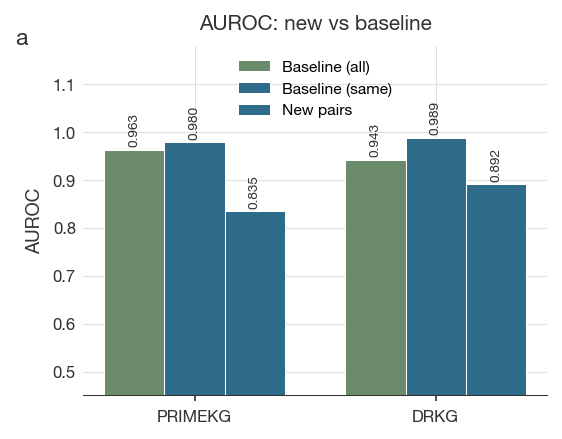

In [24]:

# Prospective generalization: AUROC baseline vs new pairs
shown_kgs = [n for n in LOADED
             if not np.isnan(temporal_metrics_kg.get(n, {}).get('auroc', np.nan))]

AUROC_BARS = [
    ('Baseline (all)',  baseline_all_kg,      OI_GREEN),
    ('Baseline (same)', baseline_same_kg,     OI_SKY_BLUE),
    ('New pairs',       temporal_metrics_kg,  OI_BLUE),
]
x = np.arange(len(shown_kgs))
w = 0.25

fig, ax = plt.subplots(figsize=(3.8, 3.0))
for i, (label, src, color) in enumerate(AUROC_BARS):
    vals = [src.get(n, {}).get('auroc', np.nan) for n in shown_kgs]
    bars = ax.bar(x + i * w, vals, w, label=label, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.006,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=6.5, fontweight='bold',
                    color=TEXT_COLOR, rotation=90)

ax.set_xticks(x + w)
ax.set_xticklabels([n.upper() for n in shown_kgs], fontsize=8.5)
ax.set_ylim(0.45, 1.18)
ax.legend(fontsize=7.5, frameon=False)
_style_left_spine(ax)
clean_ax(ax, title='AUROC: new vs baseline', ylabel='AUROC')
panel_label(ax, 'a')
plt.tight_layout()
save_fig(fig, FIGS, '07a_prospective_auroc')
plt.show()


  → Saved: 07b_prospective_hits_at_k.pdf / .png


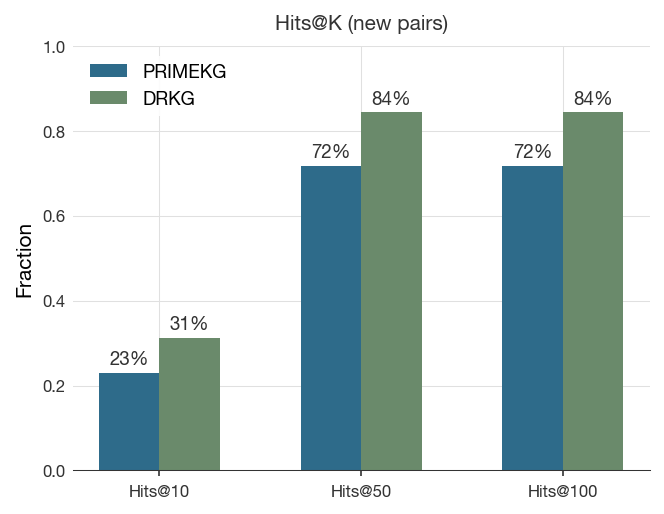

In [40]:
# Prospective generalization: Hits@K
K_KEYS   = ['hits@10', 'hits@50', 'hits@100']
K_LABELS = ['Hits@10', 'Hits@50', 'Hits@100']

# Only PrimeKG and DRKG have sufficient pairs
prospective_kgs = [n for n in shown_kgs if n in temporal_metrics_kg
                   and temporal_metrics_kg[n].get('hits@10') is not None]

x   = np.arange(len(K_KEYS))
w_h = 0.30

fig, ax = plt.subplots(figsize=(4.5, 3.5))
for i, name in enumerate(prospective_kgs):
    m    = temporal_metrics_kg.get(name, {})
    vals = [m.get(k, np.nan) for k in K_KEYS]
    bars = ax.bar(x + i * w_h, [v if not np.isnan(v) else 0 for v in vals], w_h,
                  label=name.upper(), color=KG_COLORS[name],
                  edgecolor='none', linewidth=0)
    for bar, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{v:.0%}', ha='center', va='bottom',
                    fontsize=9, color=TEXT_COLOR)

ax.set_xticks(x + w_h * (len(prospective_kgs) - 1) / 2)
ax.set_xticklabels(K_LABELS, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Fraction', fontsize=10)
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
_style_left_spine(ax)
clean_ax(ax, title='Hits@K (new pairs)')
plt.tight_layout()
save_fig(fig, FIGS, '07b_prospective_hits_at_k')
plt.show()

  → Saved: 07c_prospective_rank_dist.pdf / .png


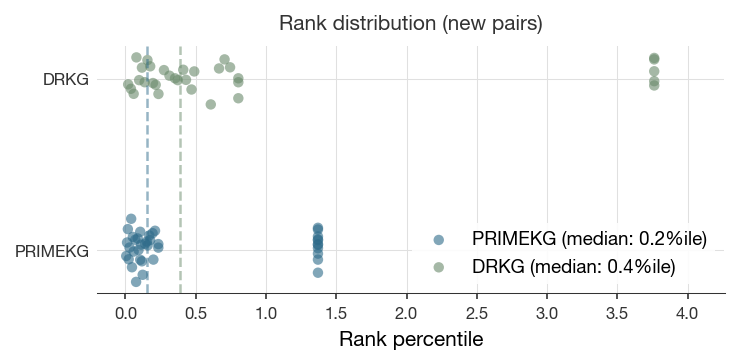

In [39]:
fig, ax = plt.subplots(figsize=(5, 2.5))

for i, (name, pct) in enumerate(pct_data.items()):
    med = np.median(pct)
    ax.scatter(pct, np.random.normal(i, 0.08, size=len(pct)),
               color=KG_COLORS[name], alpha=0.6, s=25, edgecolors='none',
               label=f'{name.upper()} (median: {med:.1f}%ile)')
    ax.axvline(med, color=KG_COLORS[name], ls='--', lw=1.2, alpha=0.5)

ax.set_yticks(range(len(pct_data)))
ax.set_yticklabels([n.upper() for n in pct_data.keys()], fontsize=10)
ax.set_xlabel('Rank percentile', fontsize=10)
ax.set_xlim(-0.2, max(all_pct) + 0.5)
_style_left_spine(ax)
clean_ax(ax, title='Rank distribution (new pairs)')
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
plt.tight_layout()
save_fig(fig, FIGS, '07c_prospective_rank_dist')
plt.show()

### Checkpoint

In [27]:
# Checkpoint — save scalar generalization results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

def _scalars(metrics: dict) -> dict:
    '''Strip non-scalar values from a metrics dict.'''
    return {k: float(v) for k, v in metrics.items()
            if isinstance(v, (int, float)) and not hasattr(v, '__len__')}

def _safe_mean(vals):
    '''Mean of non-NaN values, or NaN if empty.'''
    clean = [v for v in vals if not (isinstance(v, float) and np.isnan(v))]
    return np.mean(clean) if clean else np.nan

# ── Sub-scores (one per generalisation axis) ──────────────────────────
sub_scores = {}
for name in LOADED:
    # 1. Data-sparse: Q1 (sparse tier) AUROC
    q1_auroc = tier_results_kg.get(name, {}).get('Q1: Sparse', {}).get('auroc', np.nan)

    # 2. Cross-domain: mean AUROC across therapeutic areas
    area_aurocs = [
        m.get('auroc', np.nan)
        for m in area_results_kg.get(name, {}).values()
        if not np.isnan(m.get('auroc', np.nan))
    ]
    cd_auroc = np.mean(area_aurocs) if area_aurocs else np.nan

    # 3. Prospective: AUROC on post-cutoff FDA approval pairs
    #    NaN if KG had fewer than MIN_PAIRS evaluable pairs (unreliable estimate)
    tmp_auroc = temporal_metrics_kg.get(name, {}).get('auroc', np.nan)

    sub_scores[name] = {
        'data_sparse_gen':  round(float(q1_auroc), 4)  if not np.isnan(q1_auroc)  else np.nan,
        'cross_domain_gen': round(float(cd_auroc), 4)   if not np.isnan(cd_auroc)  else np.nan,
        'temporal_gen':     round(float(tmp_auroc), 4)  if not np.isnan(tmp_auroc) else np.nan,
    }

# ── Summary: mean of available sub-scores (NaN sub-scores excluded) ──
summary_scores = {
    name: round(float(_safe_mean(list(ss.values()))), 4)
    for name, ss in sub_scores.items()
}

ckpt = {
    'summary_scores': summary_scores,
    'sub_scores':     sub_scores,
    'tier_scalars':   {name: {tier: _scalars(m) for tier, m in tiers.items()}
                       for name, tiers in tier_results_kg.items()},
    'area_scalars':   {name: {area: _scalars(m) for area, m in areas.items()}
                       for name, areas in area_results_kg.items()},
    'area_cv':        {name: float(v) for name, v in area_cv.items()},
}

out = CKPT_DIR / '07_generalization.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)

print(f'Checkpoint saved: {out}')
print(f'\n{"KG":12s}  {"Sparse":>8s}  {"X-Domain":>8s}  {"Prospective":>11s}  {"Summary":>8s}')
print('-' * 56)
for name in LOADED:
    ss = sub_scores[name]
    prosp = f'{ss["temporal_gen"]:.4f}' if not np.isnan(ss["temporal_gen"]) else 'N/A'
    print(f'  {name:12s}  {ss["data_sparse_gen"]:.4f}    {ss["cross_domain_gen"]:.4f}    '
          f'{prosp:>11s}    {summary_scores[name]:.4f}')

Checkpoint saved: /Users/shil6661/biokgsuite/results/checkpoints/07_generalization.pkl

KG              Sparse  X-Domain  Prospective   Summary
--------------------------------------------------------
  primekg       0.6905    0.9673         0.8348    0.8309
  hetionet      0.7835    0.9089            N/A    0.8462
  drkg          0.5607    0.9625         0.8920    0.8051
  openbilink    0.6416    0.8387            N/A    0.7401
  biokg         0.6749    0.8793            N/A    0.7771


## Dimension Score

The **Generalisation** dimension score aggregates three complementary axes, each
measured as an AUROC in $[0, 1]$:

| Sub-score | Metric | Rationale |
|-----------|--------|-----------|
| **Data-sparse generalisation** | AUROC on Q1 (sparse-tier) diseases | Measures performance on rare / under-represented diseases — the hardest generalisation setting |
| **Cross-domain generalisation** | Mean AUROC across therapeutic areas | Captures whether predictive power is consistent across disease domains |
| **Prospective generalisation** | AUROC on post-cutoff FDA approvals | Tests prospective validity — whether the KG predicts indications approved after its data freeze |

$$
S_{\text{gen}}(g) \;=\; \frac{1}{3}\!\left(
   \text{AUROC}_{\text{Q1}}(g)
   \;+\; \overline{\text{AUROC}}_{\text{area}}(g)
   \;+\; \text{AUROC}_{\text{prospective}}(g)
\right)
$$

All sub-scores are saved in `sub_scores[kg]` for the summary heatmap in notebook 00.